# Super-Coherence

In [1]:
# Imports
%load_ext autoreload
%autoreload 2

from tqdm import tqdm

from core import *

In [2]:
# Configure logger
logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger()

## Comparison between regular 1D, 2D and 3D lattices

In [25]:
N = 4096  # Number of two-level systems (TLS)
J = -1  # Coupling strength

sigmas = np.linspace(0.1, 2, 20, endpoint=True)  # Frequency disorder
F_1D, F_2D, F_3D = [], [], []

Hfree = free_hamiltonian_disorder(N, distribution_type="gaussian")

for sigma in tqdm(sigmas):
    # Hamiltonian components
    Hint_1D = interaction_xy_nearest_neighbor(N, J, dimension=1)
    Hint_2D = interaction_xy_nearest_neighbor(N, J, dimension=2)
    Hint_3D = interaction_xy_nearest_neighbor(N, J, dimension=3)

    # Compute spectral function
    H_1D = sigma * Hfree + Hint_1D
    E_1D, chi_1D = LinearResponse(H_1D).spectral_delta_ground_state()
    F_1D.append(np.max(np.abs(chi_1D)))
    H_2D = sigma * Hfree + Hint_2D
    E_2D, chi_2D = LinearResponse(H_2D).spectral_delta_ground_state()
    F_2D.append(np.max(np.abs(chi_2D)))
    H_3D = sigma * Hfree + Hint_3D
    E_3D, chi_3D = LinearResponse(H_3D).spectral_delta_ground_state()
    F_3D.append(np.max(np.abs(chi_3D)))

100%|██████████| 20/20 [31:01<00:00, 93.08s/it]


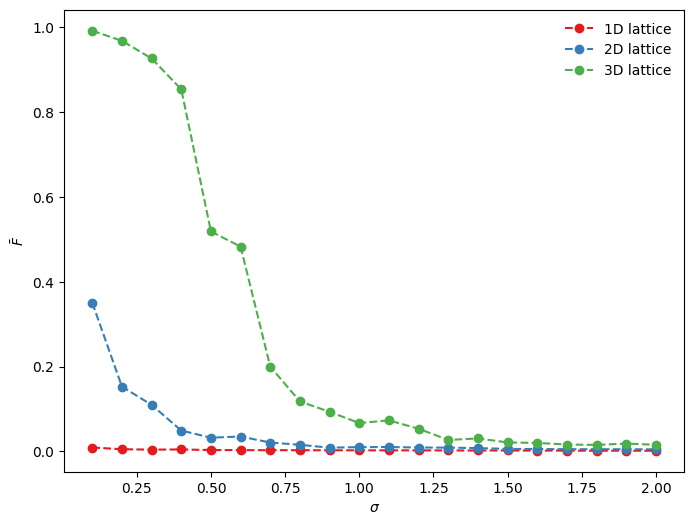

In [46]:
# Visualize results
cmap = plt.get_cmap("Set1")
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(sigmas, F_1D, label="1D lattice", marker="o", linestyle="--", color=cmap(0))
ax.plot(sigmas, F_2D, label="2D lattice", marker="o", linestyle="--", color=cmap(1))
ax.plot(sigmas, F_3D, label="3D lattice", marker="o", linestyle="--", color=cmap(2))
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\bar{F}$")
ax.legend(frameon=False)
plt.show()

In [93]:
# Analyze convergence as a function of the number of qubits N
J = -1  # Coupling strength
sigma = 0.1  # Frequency disorder

F_1D, F_2D, F_3D = [], [], []
Ns_1D = np.linspace(64, 7826, 8, endpoint=True, dtype=int)
Ns_2D = np.linspace(8, 88, 8, endpoint=True, dtype=int) ** 2
Ns_3D = np.linspace(4, 20, 8, endpoint=True, dtype=int) ** 3

# Compute for 1D
print("Computing 1D lattice ...")
for N in tqdm(Ns_1D):
    Hfree = free_hamiltonian_disorder(N, distribution_type="gaussian")
    Hint_1D = interaction_xy_nearest_neighbor(N, J, dimension=1)
    H_1D = sigma * Hfree + Hint_1D
    E_1D, chi_1D = LinearResponse(H_1D).spectral_delta_ground_state()
    F_1D.append(np.max(np.abs(chi_1D)))

# Compute for 2D
print("Computing 2D lattice ...")
for N in tqdm(Ns_2D):
    Hfree = free_hamiltonian_disorder(N, distribution_type="gaussian")
    Hint_2D = interaction_xy_nearest_neighbor(N, J, dimension=2)
    H_2D = sigma * Hfree + Hint_2D
    E_2D, chi_2D = LinearResponse(H_2D).spectral_delta_ground_state()
    F_2D.append(np.max(np.abs(chi_2D)))

# Compute for 3D
print("Computing 3D lattice ...")
for N in tqdm(Ns_3D):
    Hfree = free_hamiltonian_disorder(N, distribution_type="gaussian")
    Hint_3D = interaction_xy_nearest_neighbor(N, J, dimension=3)
    H_3D = sigma * Hfree + Hint_3D
    E_3D, chi_3D = LinearResponse(H_3D).spectral_delta_ground_state()
    F_3D.append(np.max(np.abs(chi_3D)))

Computing 1D lattice ...


100%|██████████| 8/8 [07:13<00:00, 54.21s/it] 


Computing 2D lattice ...


100%|██████████| 8/8 [05:41<00:00, 42.65s/it]


Computing 3D lattice ...


100%|██████████| 8/8 [04:24<00:00, 33.10s/it]


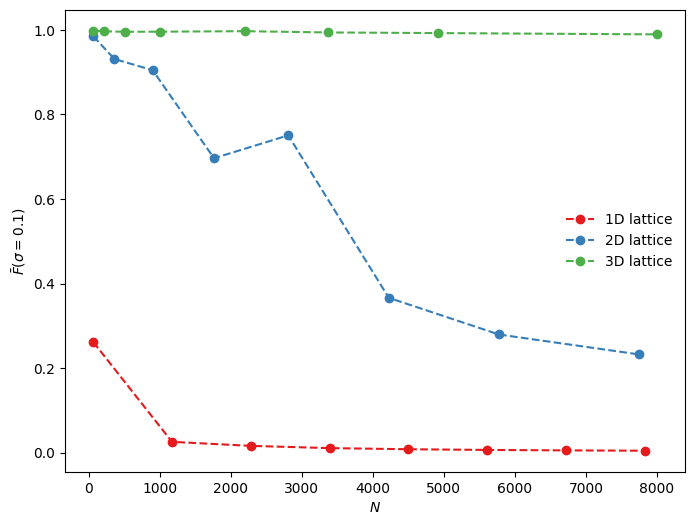

In [94]:
# Visualize results
cmap = plt.get_cmap("Set1")
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
ax.plot(Ns_1D, F_1D, label="1D lattice", marker="o", linestyle="--", color=cmap(0))
ax.plot(Ns_2D, F_2D, label="2D lattice", marker="o", linestyle="--", color=cmap(1))
ax.plot(Ns_3D, F_3D, label="3D lattice", marker="o", linestyle="--", color=cmap(2))
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\bar{F}(\sigma=0.1)$")
ax.legend(frameon=False)
plt.show()

In [4]:
# Repeat for 3D lattice only with larger number of qubits
J = -1  # Coupling strength
sigmas = np.linspace(0.1, 1, 10, endpoint=True)  # Frequency disorder

F_3D = []
Ls = np.linspace(100, 150, 2, endpoint=True, dtype=int)

# Compute for 3D
print("Computing 3D lattice ...")
for L in tqdm(Ls):
    N = L ** 3
    print(f"{L}×{L}×{L} lattice ...")
    Hfree = free_hamiltonian_disorder(N, distribution_type="gaussian", sparse=True)
    Hint_3D = interaction_xy_nearest_neighbor(N, J, dimension=3, sparse=True)

    F = []
    for sigma in tqdm(sigmas):
        print(f"{N} qubits with σ={sigma:.1f} ...")
        H_3D = sigma * Hfree + Hint_3D
        E_3D, chi_3D = LinearResponse(H_3D).spectral_delta_ground_state()
        F.append(np.max(np.abs(chi_3D)))
    F_3D.append(F)

Computing 3D lattice ...


  0%|          | 0/2 [00:00<?, ?it/s]

100×100×100 lattice ...



  0%|          | 0/10 [00:00<?, ?it/s]

1000000 qubits with σ=0.1 ...


...


 80%|████████  | 8/10 [3:46:08<18:40, 560.40s/it]

3375000 qubits with σ=0.9 ...



 90%|█████████ | 9/10 [3:47:31<06:51, 411.06s/it]

3375000 qubits with σ=1.0 ...



100%|██████████| 2/2 [4:36:27<00:00, 8293.65s/it]


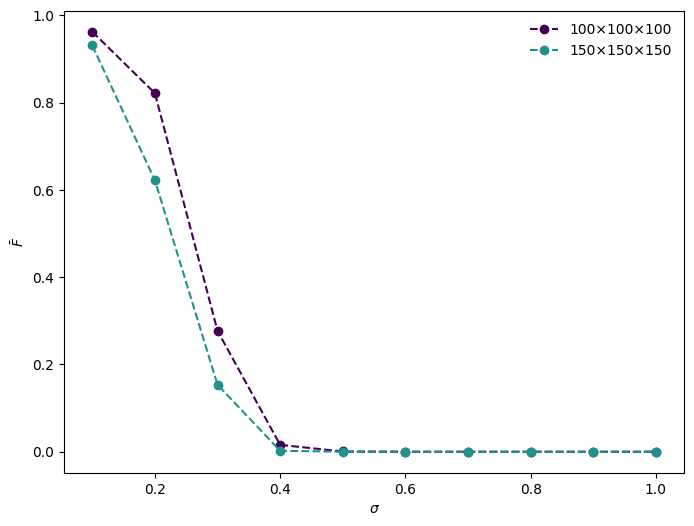

In [5]:
# Visualize results
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for idx, F in enumerate(F_3D):
    ax.plot(sigmas, F, label=f"{Ls[idx]}×{Ls[idx]}×{Ls[idx]}", marker="o", linestyle="--", color=cmap(idx / len(F_3D)))
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$\bar{F}$")
ax.legend(frameon=False)
plt.show()

In [101]:
N_1D = 60
Hfree_1D = free_hamiltonian_disorder(N_1D, distribution_type="gaussian")
Hint_1D = interaction_xy_nearest_neighbor(N_1D, J, dimension=1)
H_1D = sigma * Hfree_1D + Hint_1D
E_1D, chi_1D = LinearResponse(H_1D).spectral_delta_ground_state()
print(np.max(np.abs(chi_1D)))

N_2D = 3600
Hfree_2D = free_hamiltonian_disorder(N_2D, distribution_type="gaussian")
Hint_2D = interaction_xy_nearest_neighbor(N_2D, J, dimension=2)
H_2D = sigma * Hfree_2D + Hint_2D
E_2D, chi_2D = LinearResponse(H_2D).spectral_delta_ground_state()
print(np.max(np.abs(chi_2D)))

0.2629232693988891
0.41305572928366896
